# GPT2 Experiments

## Introduction

I state that the current model scale of my experimentation is too small, that given I am only tested the redundancy across 4 heads that this scale of experiment is too small to fully quantify if my idea of applying a MLA inspired compress/decompress bottleneck to the output projection achieves a reduction in the number of model parameters while retaining the models quality. 

To avoid a costly large scale runs, I wish to establish if this might work before the fact, by leveraging already trained models and replacing their output projection matrices with lower rank matrices of different levels of reduction, and then evaluating these models on an evaluation dataset. I will be evaluating the GPT2 small, medium and large models which have 12, 16 and 20 attention heads respectively per model layer, much larger than the 4 that I have been evaluating in my experiment.

Therefore, in this notebook I will first take a trained model, GPT2 Small, Medium and Large, and replace their respective output projection matrix with a lower rank matrix of size $r$, where $r$ represents the fraction of full rank of the matrix. Perplexity will be evaluated on the wikitext-103-raw-v1 evaluation dataset after the replacement. The idea being if I can show that the perplexity curve against $r$, the fraction of full rank, show a similar or different pattern across the three models. Ideally, the curves will remain flat for a large portion of the rank percentages and especially we want to see the larger models stay flat for longer. This would confirm that my experimentation may work and would be worth exploring further.

Each model will also be finetuned on the training data from wikitext-103-raw-v1 for a fix small number of steps approx 200. The idea being that the model will adapt to this new dataset with the new architecture.

Below I will be plotting the pre-finetuning and post finetuning perplexity values for all three models against the fraction of rank $r$. This allows for easy comparison of perplexity curves across the three models. Similarly, I normalise the perplexity scores for each model to allow for easy comparison of each models robustness to compression, i.e. percentage of full rank perplexity, where the norm value for $r=1$ is 1. This represents a relative degradation of the full rank perplexity.  

## Define the necessary libraries

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

## Plotting Utils

In [17]:
df = pd.read_csv("data/svd_probe_results.csv").drop_duplicates(subset=["model", "r"], keep="last").sort_values("r").reset_index(drop=True)

In [19]:
df

,model,r,actual_loss,actual_ppl,finetuning_loss,finetuning_ppl
0,gpt2-large,0.03125,7.734977,2286.955094,3.445632,31.363112
1,gpt2-medium,0.03125,6.226871,506.169350,3.772930,43.507358
2,gpt2,0.03125,7.008114,1105.566926,4.398792,81.352520
3,gpt2-medium,0.06250,5.258246,192.144166,3.304462,27.233899
4,gpt2,0.06250,6.630466,757.835050,3.888921,48.858162
5,gpt2-large,0.06250,6.116286,453.178667,3.050893,21.134208
6,gpt2-large,0.12500,3.744033,42.268105,2.802754,16.489994
7,gpt2-medium,0.12500,4.014526,55.397051,3.009796,20.283259
8,gpt2,0.12500,5.774302,321.919765,3.468074,32.074905
9,gpt2-large,0.25000,3.164284,23.671798,2.686481,14.679923


In [24]:
colors

{'gpt2': array([0.267004, 0.004874, 0.329415, 1.      ]),
 'gpt2-large': array([0.127568, 0.566949, 0.550556, 1.      ]),
 'gpt2-medium': array([0.993248, 0.906157, 0.143936, 1.      ])}

In [25]:
base = df[df["r"] == 1.0].set_index("model")["actual_ppl"]

In [26]:
base

model
gpt2           30.479309
gpt2-large     19.240845
gpt2-medium    22.244309
Name: actual_ppl, dtype: float64

In [27]:
df = df.assign(
        norm_pre=df.apply(lambda x: x["actual_ppl"] / base.get(x["model"]), axis=1),
        norm_post=df.apply(lambda x: x["finetuning_ppl"] / base.get(x["model"]), axis=1),
    )

In [28]:
df

,model,r,actual_loss,actual_ppl,finetuning_loss,finetuning_ppl,norm_pre,norm_post
0,gpt2-large,0.03125,7.734977,2286.955094,3.445632,31.363112,118.859390,1.630028
1,gpt2-medium,0.03125,6.226871,506.169350,3.772930,43.507358,22.755004,1.955887
2,gpt2,0.03125,7.008114,1105.566926,4.398792,81.352520,36.272703,2.669106
3,gpt2-medium,0.06250,5.258246,192.144166,3.304462,27.233899,8.637902,1.224309
4,gpt2,0.06250,6.630466,757.835050,3.888921,48.858162,24.863919,1.602994
5,gpt2-large,0.06250,6.116286,453.178667,3.050893,21.134208,23.552950,1.098403
6,gpt2-large,0.12500,3.744033,42.268105,2.802754,16.489994,2.196790,0.857031
7,gpt2-medium,0.12500,4.014526,55.397051,3.009796,20.283259,2.490392,0.911840
8,gpt2,0.12500,5.774302,321.919765,3.468074,32.074905,10.561912,1.052350
9,gpt2-large,0.25000,3.164284,23.671798,2.686481,14.679923,1.230289,0.762956


In [31]:
from matplotlib.ticker import NullLocator

In [47]:
def plot_results(path="data/svd_probe_results.csv", save_path="data/svd_probe_plot.png"):
    """
    Plot the results of the test run and compare the perplexities across different levels of r (rank fraction).
    """
    COLORS = {
        "gpt2":        "#1f77b4",
        "gpt2-medium": "#ff7f0e",
        "gpt2-large":  "#2ca02c",
    }

    # Import the dataset
    df = pd.read_csv(path).drop_duplicates(subset=["model", "r"], keep="last").sort_values("r").reset_index(drop=True)

    # Precompute normalized columns
    base_ppl = df[df["r"] == 1.0].set_index("model")["actual_ppl"]
    df = df.assign(
        norm_pre=df.apply(lambda x: x["actual_ppl"] / base_ppl.get(x["model"]), axis=1),
        norm_post=df.apply(lambda x: x["finetuning_ppl"] / base_ppl.get(x["model"]), axis=1),
    )

    # Plotting
    fig, axes = plt.subplots(4, 1, figsize=(12, 20))
    ax_raw_pre, ax_raw_post, ax_norm_pre, ax_norm_post = axes
    label = lambda m, d: m
    for m in sorted(df["model"].unique()):
        d = df[df["model"] == m].sort_values("r")
        ax_raw_pre.plot(d["r"],   d["actual_ppl"],      "-o", color=colors[m], label=label(m, d))
        ax_raw_post.plot(d["r"],  d["finetuning_ppl"],  "-o", color=colors[m], label=label(m, d))
        ax_norm_pre.plot(d["r"],  d["norm_pre"],        "-o", color=colors[m])
        ax_norm_post.plot(d["r"], d["norm_post"],       "-o", color=colors[m])

    ax_raw_pre.set_title("Raw perplexity - pre-finetune (immediate)")
    ax_raw_post.set_title("Raw perplexity - post-finetune (healed)")
    ax_norm_pre.set_title("Normalised to full rank - pre-finetune")
    ax_norm_post.set_title("Normalised to full rank - post-finetune (healed)")

    r_vals = sorted(df["r"].unique(), reverse=True)
    for ax in axes:
        ax.set_xscale("log", base=2)
        ax.grid(True, alpha=0.3)
        ax.set_xticks(r_vals)
        ax.set_xticklabels([f"{r:g}" for r in r_vals])
        ax.xaxis.set_minor_locator(NullLocator())
        ax.set_xlim(1.05, df["r"].min() * 0.85)
        ax.set_xlabel("rank fraction  r / d_model")

    for ax in (ax_raw_pre, ax_raw_post):
        ax.set_ylabel("WikiText perplexity")
    for ax in (ax_norm_pre, ax_norm_post):
        ax.set_ylabel("perplexity / full-rank perplexity")
        ax.axhline(1.0, color="grey", lw=0.8, ls=":")

    # healed panels get their OWN tight range so they're easy to compare
    pad = lambda s, k=0.03: (s.min() - abs(s.min())*k, s.max() + abs(s.max())*k)
    ax_raw_post.set_ylim(*pad(df["finetuning_ppl"]))
    ax_norm_post.set_ylim(*pad(df["norm_post"]))

    ax_raw_pre.legend(fontsize=9, loc="upper left")
    fig.suptitle(r"$W^O$ low-rank truncation: pre vs post finetune", y=0.997, fontsize=14)
    fig.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

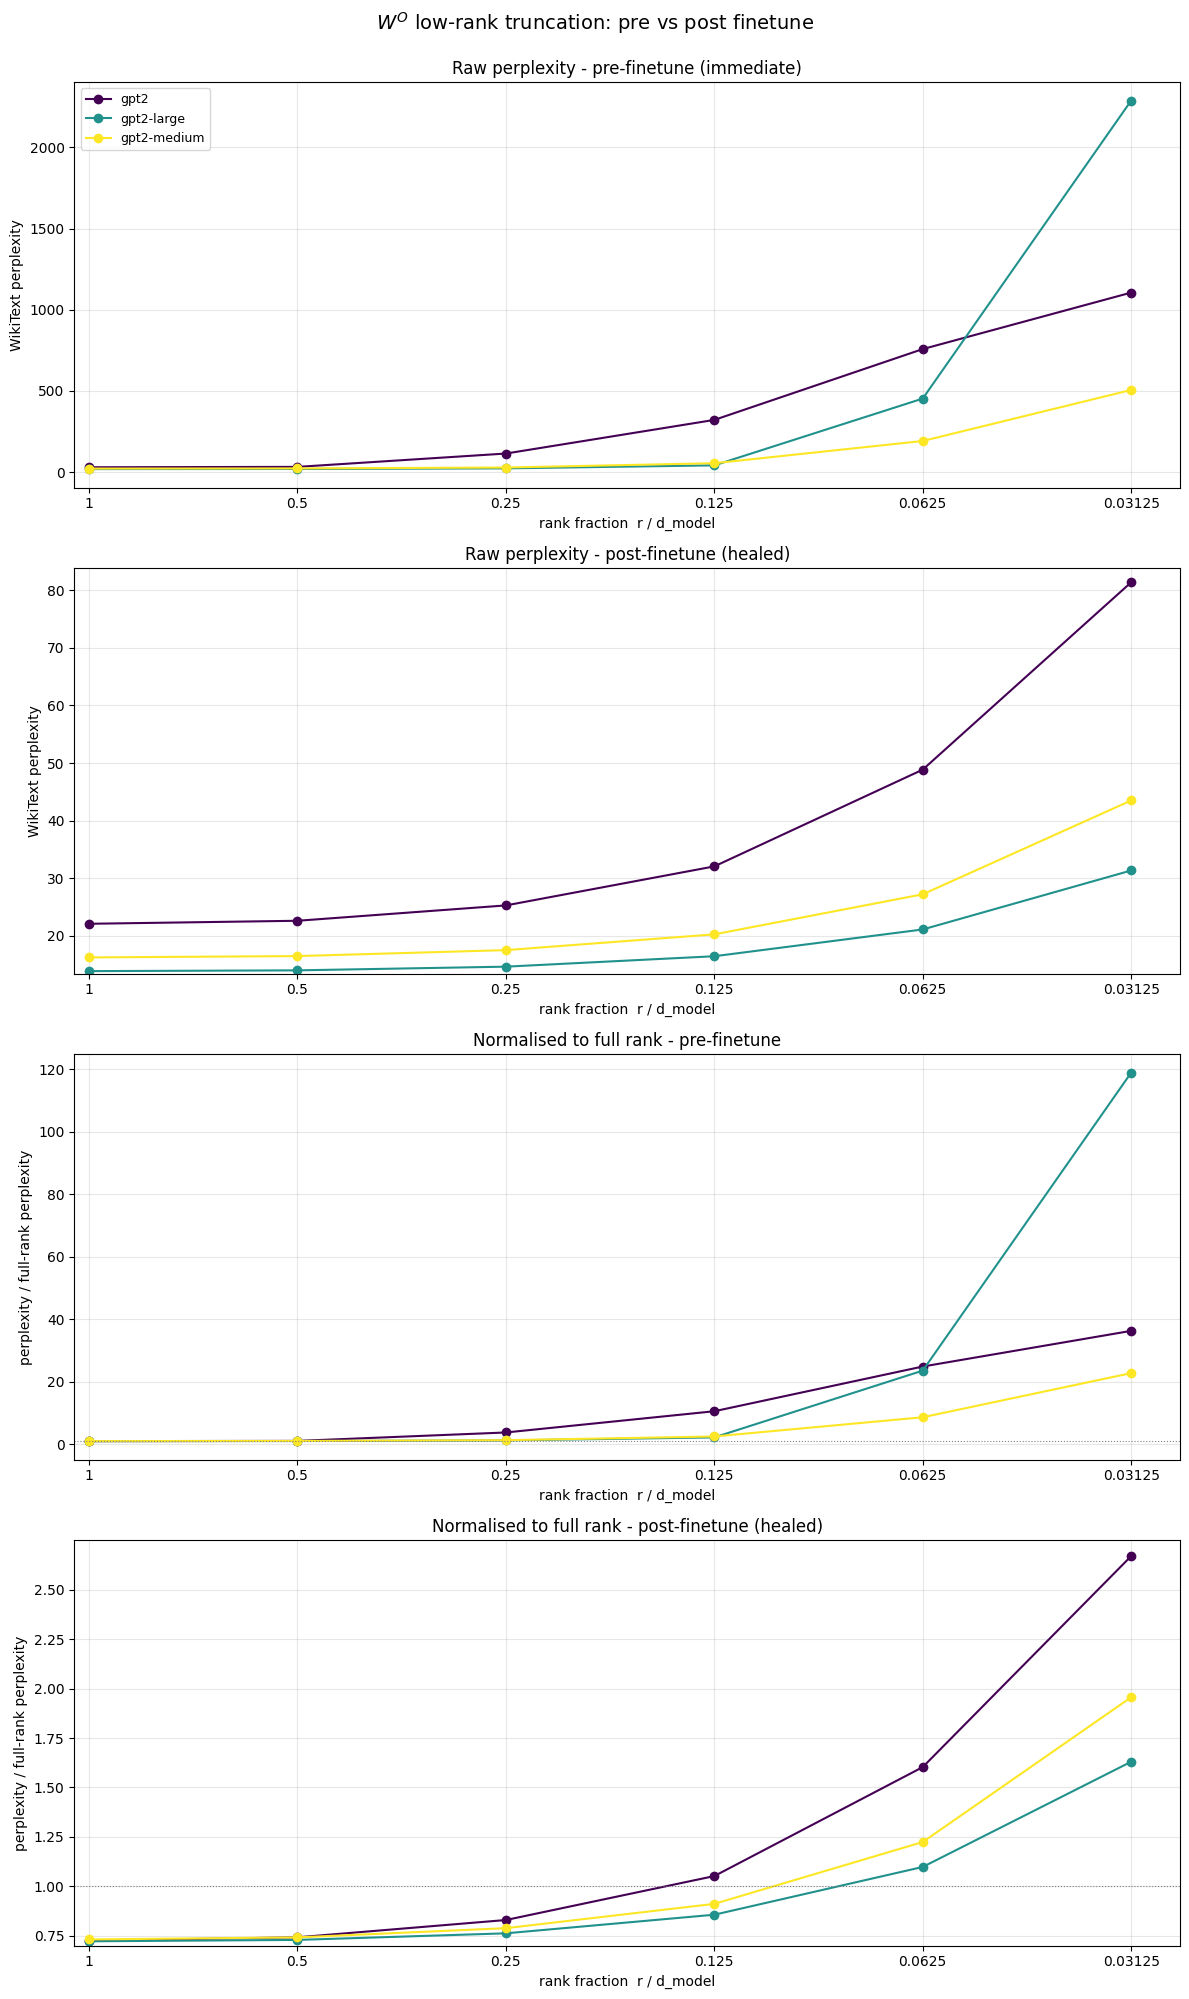

In [48]:
# Plot the results
plot_results()

## Conclusion

Examining the plots above, I can see that as one might expect for the pre finetuned raw perplexity scores (plot 1) that GPT2-Small's perplexity increases at a greater pace when compared with GPT2-Medium and GPT2-Large. We can see that GPT2-Medium and GPT2-Large remain relatively close until $r=0.125$ where they diverge. While GPT2-Small diverges from the rest at $r=0.5$. This is an initial positive sign that there appears to be different levels of reduction in model perplexity as the rank fraction $r$ is reduced.

Finetining after replacing the output projection matrix with a reduced rank matrix helps the model adapt to its new weights matrix, and we can see this in plot 2. The exploring perplexity value for $r=0.3125$ for GPT2-Large has been reduced back down. Overall the three models follow a similar reduction in perplexity as $r$ decreases with the models appearing to diverge around 0.25. This result would be in line with that one might expect, larger model performs better than medium which in turn performs better than small.

For a fairer comparison, we compare the normalised perplexity scores, and thus compare the percentage reduction relative to the models full rank perplexity. I can draw similar, conclusions to the first plot, with GPT2-Small starting to diverge at $r=0.5$ and GPT2 Medium and Large diverging at $r=0.125$.

Similarly, for the finetuned results, normalised on the full rank perplexity for their respective model, this suggests that each model obtains a better perplexity score relative to the full rank model up to $r=0.25$ for GPT2-Small and $r=0.5$ for GPT2 Medium and Large. The models appear to be relatively similar in relative reduction in perplexity up to $r=0.25$ after which they start to diverge.

Overall, these results bode well for scaling my experiment to a larger scale. However, these experiements do not account for the fact that these performance differences are solely related to an increase in the number of attention heads, given that the models also increase in layers and thus overall number of parameters. Thus, I will need to run an experiment to confirm this by keeping d_model, depth, and parameter count fixed, and vary only n_head.